In [1]:
import sys
sys.path.append("/home/nasia/wine-innovation-engine")
import importlib
import src.process.simulator as sim
importlib.reload(sim)
from src.process.simulator import rhs, params, run_simulation, STATE_NAMES
import numpy as np
import matplotlib.pyplot as plt
from src.process.simulator import rhs, params, run_simulation, STATE_NAMES




In [2]:
sol = run_simulation()        # default params, t_end = 600 h
t = sol.t
X, Xt, S, N, E = sol.y

print(f"Solver succeeded: {sol.success}")
print(f"Time points: {len(t)}  |  span: {t[0]:.0f}–{t[-1]:.0f} h")

Solver succeeded: True
Time points: 703  |  span: 0–700 h


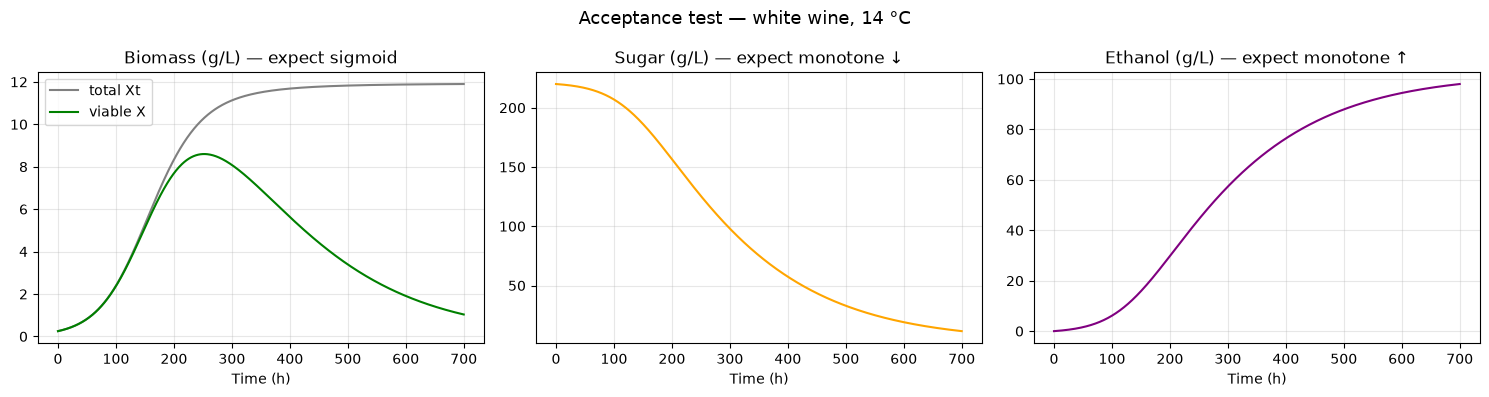

In [3]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Acceptance test — white wine, 14 °C", fontsize=13)

ax[0].plot(t, Xt, color="gray", label="total Xt")
ax[0].plot(t, X, color="green", label="viable X")
ax[0].set_title("Biomass (g/L) — expect sigmoid")
ax[0].legend()

ax[1].plot(t, S, color="orange")
ax[1].set_title("Sugar (g/L) — expect monotone ↓")

ax[2].plot(t, E, color="purple")
ax[2].set_title("Ethanol (g/L) — expect monotone ↑")

for a in ax:
    a.set_xlabel("Time (h)"); a.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


 CODE TEST: RK45 SOLVER maybe has some noise and not real increasement of sugar ,so we put 1e-6
 

In [4]:
tol=1e-6 #we say It's okay if the biomass drops slightly between measurements, as long as the drop isn't larger than the tolerance

sugar_ok=np.all(np.diff(S) <=tol) #sugar never increases
ethanol_ok=np.all(np.diff(E) >=-tol) #ethanol never decreases
sigmoid_ok=np.all(np.diff(Xt) >=-tol)#total biomass monotone->plateau 

print(f"Sugar monotonically decreasing : {sugar_ok}")
print(f"Ethanol monotonically increasing: {ethanol_ok}")
print(f"Total biomass monotone (sigmoid): {sigmoid_ok}")

assert sugar_ok and ethanol_ok and sigmoid_ok, "Acceptance test FAILED — debug before moving on."
print("\n✅ Acceptance test PASSED")

Sugar monotonically decreasing : True
Ethanol monotonically increasing: True
Total biomass monotone (sigmoid): True

✅ Acceptance test PASSED


In [5]:
final_ethanol = E[-1]
abv = final_ethanol / 7.89                       # g/L → % v/v (ethanol ρ ≈ 0.789 g/mL)
residual_sugar = max(S[-1],0.0)  # g/L, avoid negative values due to numerical noise

# time to "dry" (residual sugar < 4 g/L, oenological dryness threshold)
dry_idx = np.argmax(S < 4.0) if np.any(S < 4.0) else -1
time_to_dry = t[dry_idx] if dry_idx != -1 else np.nan

print(f"Final ethanol   : {final_ethanol:6.1f} g/L  (≈ {abv:.1f} % v/v)")
print(f"Residual sugar  : {residual_sugar:6.1f} g/L")
print(f"Time to dryness : {time_to_dry:6.0f} h  (≈ {time_to_dry/24:.1f} days)")

Final ethanol   :   98.0 g/L  (≈ 12.4 % v/v)
Residual sugar  :   11.5 g/L
Time to dryness :    nan h  (≈ nan days)


Final sugar:         11.5 g/L   (paper: ~50, stuck)
Final viable biomass: 1.04 g/L
Max viable biomass:  8.6 g/L   (paper: ~3.5)


FileNotFoundError: [Errno 2] No such file or directory: 'results/figures/fermentation_simulation_kd_prime_dependant_1.png'

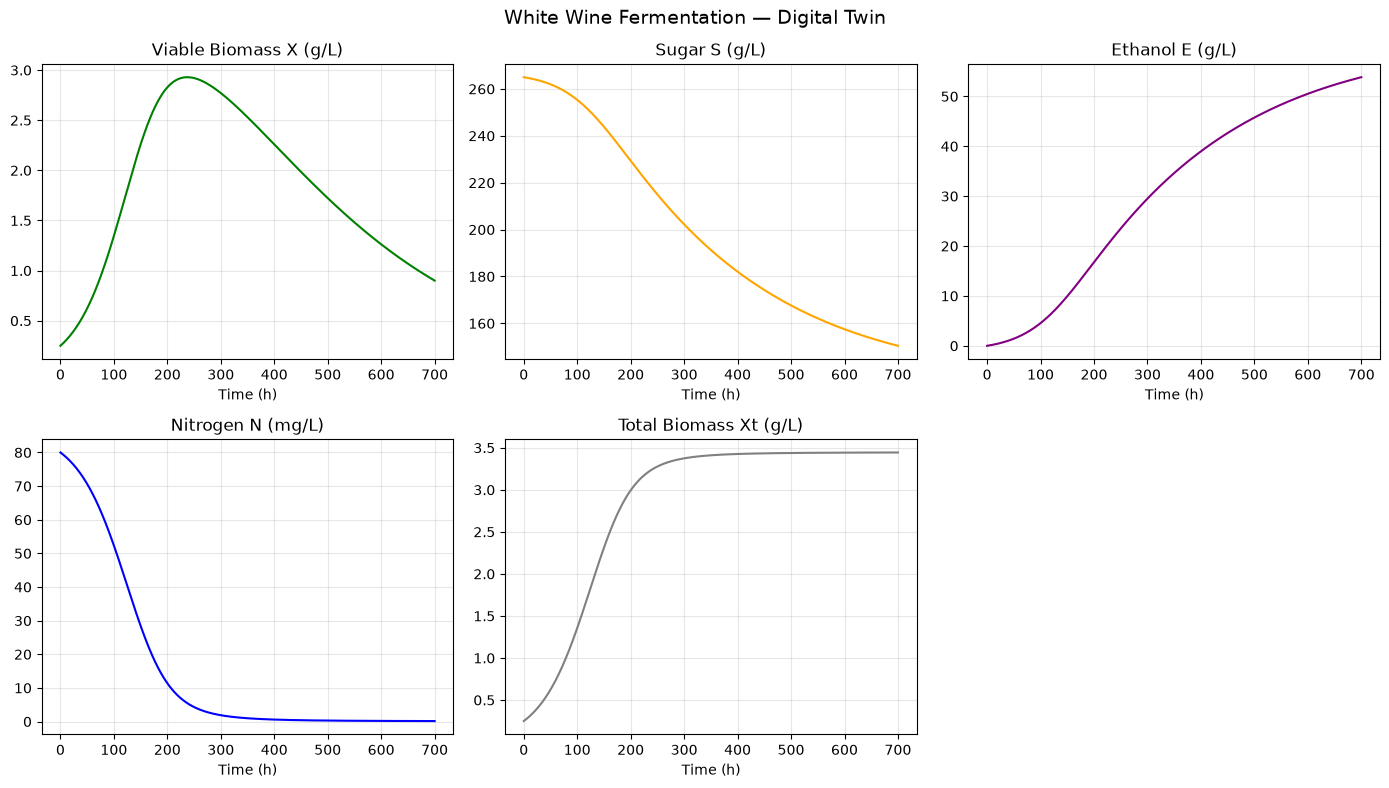

In [6]:
## Validation against Coleman Dataset 2 (Fermentation 10:269, Figure 2)
# Paper conditions: 265 g/L sugar, 80 mg/L N, 15°C
# Paper result: STUCK fermentation, ~50 g/L sugar remaining, max biomass ~3.5 g/L


from src.process.simulator import run_simulation,params,plot_simulation

p_test={**params,"S0": 265.0, "N0": 80.0, "T": 15.0} #we do this way to not change the default params in the simulator.py file, but just for this test
sol_test=run_simulation(p_test) #run the simulation with the test parameters

print("Final sugar:        ", round(sol.y[2, -1], 1), "g/L   (paper: ~50, stuck)")
print("Final viable biomass:", round(sol.y[0, -1], 2), "g/L")
print("Max viable biomass: ", round(sol.y[0].max(), 2), "g/L   (paper: ~3.5)")

plot_simulation(sol_test)


in the paper they getting stuck but mine consumes all the sugar because we add it the maintenance term that eat sugan even after growth stops 

we will run two fermentations side by side to explore the concepts of stuck(low nitrogen) and one with adequate nitrogen (complete)

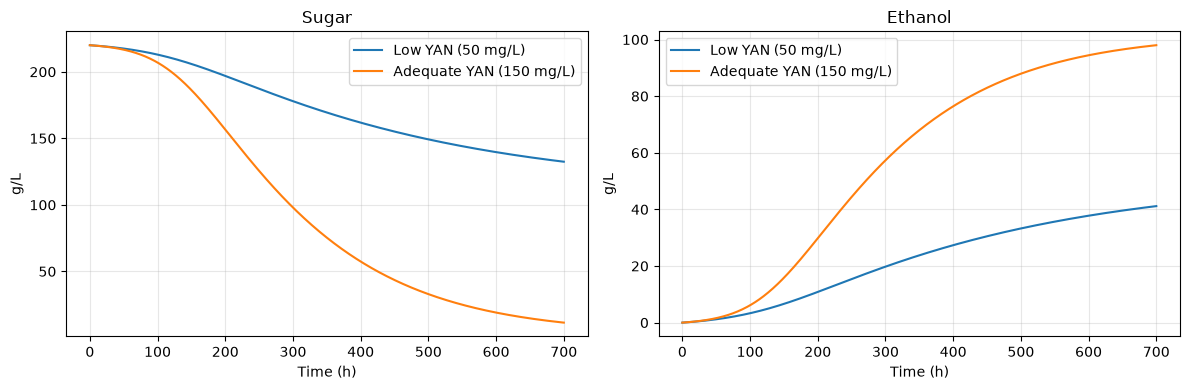

In [8]:
scenarios={
    "Low YAN (50 mg/L)":{**params,"N0":50},
    "Adequate YAN (150 mg/L)":{**params,"N0":300},
}

fig,ax=plt.subplots(1,2,figsize=(12,4))

for label,p in scenarios.items():
    sol=run_simulation(p)
    ax[0].plot(sol.t, sol.y[2], label=label)   # sugar
    ax[1].plot(sol.t, sol.y[4], label=label)   # ethanol

ax[0].set_title("Sugar"); ax[0].set_ylabel("g/L"); ax[0].legend()
ax[1].set_title("Ethanol"); ax[1].set_ylabel("g/L"); ax[1].legend()
for a in ax: a.set_xlabel("Time (h)"); a.grid(alpha=0.3)
plt.tight_layout(); plt.show()


All models include an Arrhenius temperature function that increases the maximum specific growth rate as temperatures increase; however, only the Boulton model also includes an Arrhenius temperature function to account for the observation that above a certain temperature (33 ◦C),
(Nelson & Boulton, 2024)

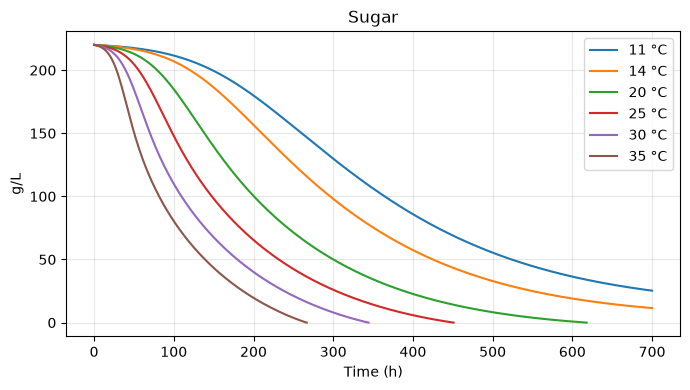

In [ ]:
#We will try different temperatures
fig,ax=plt.subplots(figsize=(7,4))

for T in [11,14,20,25,30]:
    sol=run_simulation({**params,"T":T})
    ax.plot(sol.t, sol.y[2], label=f"{T} °C")
ax.set_title("Sugar"); ax.set_ylabel("g/L"); ax.legend()
ax.set_xlabel("Time (h)"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()




f_T rises monotonically -fallof above ~33